# Practical 02: Multivariable Linear Regression

## Dataset: Diabetes Dataset
## Subject: Machine Learning

This practical demonstrates Multivariable Linear Regression using:

1. sklearn LinearRegression (Inbuilt Method)
2. Gradient Descent Optimization (Homework)


## Import Required Libraries

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

## Load Diabetes Dataset

In [2]:
data = datasets.load_diabetes()

X = data.data
y = data.target

print("Feature Names:", data.feature_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature Names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape of X: (442, 10)
Shape of y: (442,)


## Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Method 1: sklearn LinearRegression

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Predictions

In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

## Model Evaluation Metrics

In [6]:
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)
print("Training R2:", train_r2)
print("Testing R2:", test_r2)

Training MSE: 2868.549702835577
Testing MSE: 2900.193628493482
Training R2: 0.5279193863361498
Testing R2: 0.4526027629719195


## Feature Coefficient Interpretation

In [7]:
for feature, coef in zip(data.feature_names, model.coef_):
    print(f"{feature} : {coef}")

age : 37.904021350074984
sex : -241.96436231273995
bmi : 542.4287585162899
bp : 347.70384391385636
s1 : -931.4888458835163
s2 : 518.0622769833376
s3 : 163.41998299131035
s4 : 275.3179015786484
s5 : 736.1988589046839
s6 : 48.67065743196543


## Method 2: Gradient Descent (Homework)

In [8]:
X_b = np.c_[np.ones((X_train.shape[0],1)),X_train]

theta = np.zeros(X_b.shape[1])

learning_rate = 0.01
iterations = 1000

for i in range(iterations):
    gradients = 2/len(X_b) * X_b.T.dot(X_b.dot(theta)-y_train)
    theta -= learning_rate * gradients

print("Gradient Descent Parameters:",theta)

Gradient Descent Parameters: [153.49881032  13.01887738  -0.33453933  42.14936156  31.57730672
  12.70769876   9.40905473 -26.20621499  28.78399342  38.40122666
  27.18812584]


## Gradient Descent Prediction

In [9]:
X_test_b = np.c_[np.ones((X_test.shape[0],1)),X_test]

y_pred_gd = X_test_b.dot(theta)

print(y_pred_gd[:10])

[157.69219939 153.87692748 156.73195972 172.02345688 154.41957464
 151.35482039 165.43466677 163.4919669  147.16165465 151.86910201]


## Visualization: Actual vs Predicted (Test Data)

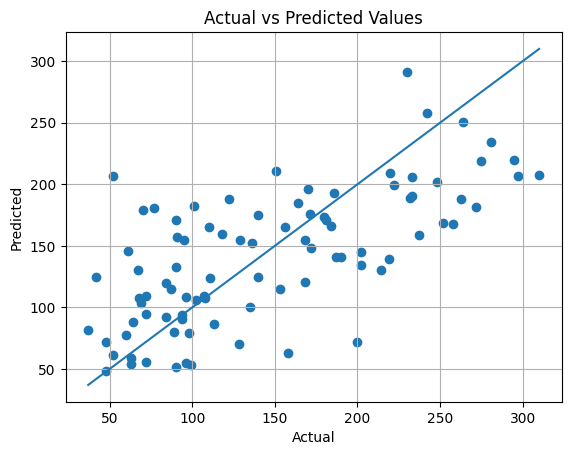

In [10]:
plt.figure()
plt.scatter(y_test, y_test_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Values")
plt.grid(True)
plt.show()

## Conclusion

Multivariable Linear Regression was successfully implemented using sklearn and gradient descent optimization. Both approaches produced comparable predictive performance.